In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from collector import BASE_PATH
import tidy_data

In [2]:
PRICE_PLOT_KWARGS = {"xlim": (0,1)}


df = pd.read_parquet(f"{BASE_PATH}/data/dataframe.parquet")

df = tidy_data.clean_columns(df)

print(df.info())

print(f"Maximum event_id: {max(df.event_id)}")



Cleaning Columns

Original: 327.661788Mb
Cleaned: 265.250044Mb
Delta: 62.411744Mb

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1950367 entries, 0 to 1950366
Data columns (total 17 columns):
 #   Column           Dtype  
---  ------           -----  
 0   event_id         int64  
 1   trade_index      int64  
 2   proxyWallet      object 
 3   side             object 
 4   asset            object 
 5   conditionId      object 
 6   size             float64
 7   price            float64
 8   timestamp        int64  
 9   title            object 
 10  slug             object 
 11  eventSlug        object 
 12  outcome          object 
 13  outcomeIndex     int64  
 14  name             object 
 15  pseudonym        object 
 16  transactionHash  object 
dtypes: float64(2), int64(4), object(11)
memory usage: 253.0+ MB
None
Maximum event_id: 5971


In [12]:
print(df.event_id)

0             0
1             0
2             0
3             0
4             0
           ... 
1950362    5971
1950363    5971
1950364    5971
1950365    5971
1950366    5971
Name: event_id, Length: 1950367, dtype: int64


In [24]:
def stats(df):
    df['value'] = df['price']*df['size']
    df['price_size_list'] =df[['price','size']].values.tolist()
    df['mean'] = df['value'].mean() 
    df['z_score'] = abs((df['value']-df['mean'])/(df['value'].std()))
    return df
    

In [27]:
def split(df):
    buys = df.loc[df.side == "BUY"].copy()
    sells = df.loc[df.side == "SELL"].copy()
    return {"buys":buys,"sells":sells}

split_df = split(df)
split_df = {"buys":stats(split_df["buys"]),"sells":stats(split_df["sells"])} #Change this shit for sure

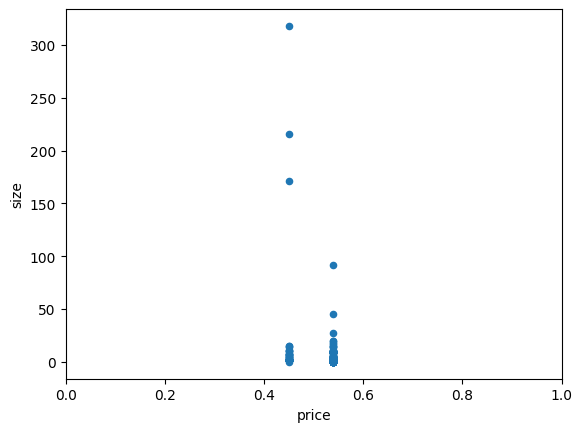

price, size: [0.45, 318.0], 
value: 143.1, 
z-score: 0.02, 
event mean: 134.99106381215714, 
conditionId: 0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992db14fb726fa895cb5763, 
title: Russia-Ukraine Ceasefire before GTA VI?, 



1

In [65]:


def graph_event(event_id : int, df : pd.DataFrame):
    
    event = df.loc[df.event_id == event_id].copy()

    if event.loc[df.event_id == event_id].empty: 
        #print("\n --------------Empty series---------------- \n")
        return 0
    
    #print(event.info())
    #print(event.z_score)
    
    event.plot.scatter(x="price",y="size", **PRICE_PLOT_KWARGS)
    
    plt.show()
    
    max_row = event.loc[event['value'].idxmax()]
    
    print(
        f"price, size: {max_row['price_size_list']}, \n"
        f"value: {max_row['value']}, \n"
        f"z-score: {max_row['z_score']:.2f}, \n"
        f"event mean: {max_row['mean']}, \n"
        f"conditionId: {max_row['conditionId']}, \n"
        f"title: {max_row['title']}, \n"
    )

    return 1

graph_event(0, split_df["sells"])


In [70]:
def outliers(df: pd.DataFrame):
    return df.loc[(df.value > 100) & (df.z_score >= 15) & (df.price < .4)].copy()
    
    

In [71]:
all_sell_outliers = outliers(split_df["sells"])
all_buy_outliers = outliers(split_df["buys"])

In [73]:
for i in range(5971):
    #print("Sells VVV")
    #graph_event(event_id=i, df = all_sell_outliers)
    #print("Buys VVV")
    graph_event(event_id=i, df = all_buy_outliers)